# Statistical Analysis (Python)

This notebook is set up for statistical analysis with **pandas**, **scipy**, **statsmodels**, and **seaborn**.

Data files live in `../data/`:

- `iris.csv` — Fisher iris measurements by species
- `wages.csv` — 1985 CPS wage determinants (534 workers)
- `brain_size.csv` — brain size and IQ measures by gender

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [3]:
DATA_DIR = Path("../data").resolve()

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", None)

print(f"Data directory: {DATA_DIR}")
print("Available files:")
for path in sorted(DATA_DIR.glob("*.csv")):
    print(f"  - {path.name}")

Data directory: /Users/coraalbers/Documents/sum26/7030_data_sci/assignment4/data
Available files:
  - brain_size.csv
  - iris.csv
  - wages.csv


## Load data

Use the helpers below to load each dataset with the correct delimiter and column names.

In [53]:
WAGES_COLUMNS = [
    "education",
    "south",
    "sex",
    "experience",
    "union",
    "wage",
    "age",
    "race",
    "occupation",
    "sector",
    "marr",
]


def load_iris() -> pd.DataFrame:
    return pd.read_csv(DATA_DIR / "iris.csv")


def load_wages() -> pd.DataFrame:
    df = pd.read_csv(
        DATA_DIR / "wages.csv",
        sep=r"\s+",
        skiprows=27,
        nrows=534,
        header=None,
        names=WAGES_COLUMNS,
        engine="python",
    )
    df["sex"] = df["sex"].map({0: "Male", 1: "Female"}).astype("string")
    df["wage"] = np.log10(df["wage"])
    return df


def load_brain_size() -> pd.DataFrame:
    df = pd.read_csv(
        DATA_DIR / "brain_size.csv",
        sep=";",
        quotechar='"',
    )
    df.columns = [col.strip('"') for col in df.columns]
    numeric_cols = ["FSIQ", "VIQ", "PIQ", "Weight", "Height", "MRI_Count"]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col].replace(".", np.nan), errors="coerce")
    return df

In [54]:
iris = load_iris()
wages = load_wages()
brain_size = load_brain_size()

print("Iris:", iris.shape)
display(iris.head())

print("\nWages:", wages.shape)
display(wages.head())

print("\nBrain size:", brain_size.shape)
display(brain_size.head())

Iris: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,name
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



Wages: (534, 11)


,education,south,sex,experience,union,wage,age,race,occupation,sector,marr
0,8,0,Female,21,0,0.707570,35,2,6,1,1
1,9,0,Female,42,0,0.694605,57,3,6,1,1
2,12,0,Male,1,0,0.824126,19,3,6,1,0
3,12,0,Male,4,0,0.602060,22,3,6,0,0
4,12,0,Male,17,0,0.875061,35,3,6,0,1



Brain size: (40, 8)


,Unnamed: 0,Gender,FSIQ,VIQ,PIQ,Weight,Height,MRI_Count
0,1,Female,133,132,124,118.0,64.5,816932
1,2,Male,140,150,124,NaN,72.5,1001121
2,3,Male,139,123,150,143.0,73.3,1038437
3,4,Male,133,129,128,172.0,68.8,965353
4,5,Female,137,132,134,147.0,65.0,951545


## Brain size analysis

Group the brain size data by gender and compute mean values for each numeric measure.

In [6]:
numeric_cols = ["FSIQ", "VIQ", "PIQ", "Weight", "Height", "MRI_Count"]

gender_means = brain_size.groupby("Gender")[numeric_cols].mean()
display(gender_means)

,FSIQ,VIQ,PIQ,Weight,Height,MRI_Count
Gender,,,,,,
Female,111.9,109.45,110.45,137.200000,65.765000,862654.6
Male,115.0,115.25,111.60,166.444444,71.431579,954855.4


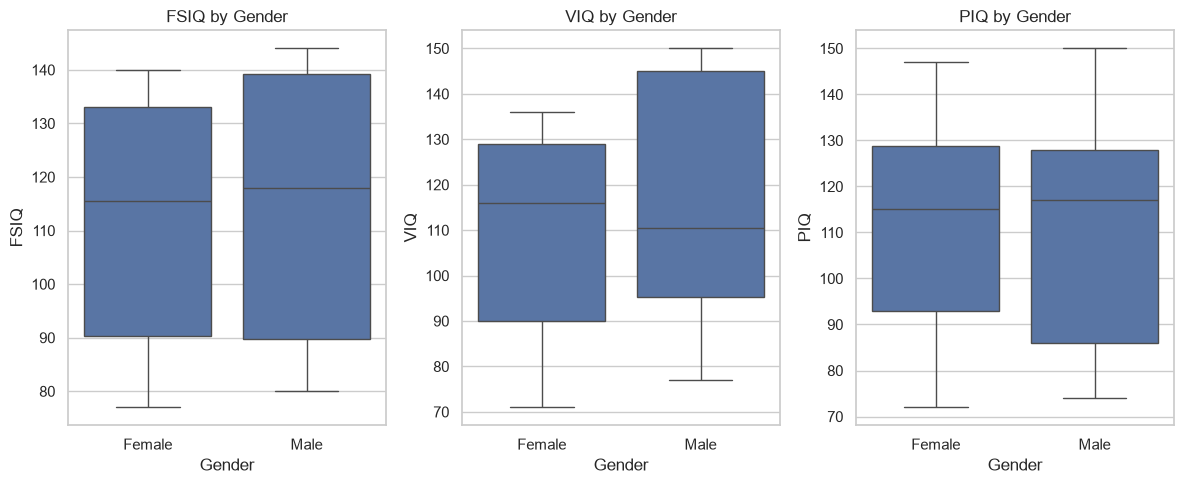

In [7]:
iq_cols = ["FSIQ", "VIQ", "PIQ"]

fig, axes = plt.subplots(1, 3, figsize=(12, 5))

for ax, col in zip(axes, iq_cols):
    sns.boxplot(data=brain_size, x="Gender", y=col, ax=ax)
    ax.set_title(f"{col} by Gender")

plt.tight_layout()
plt.show()

In [8]:
viq_mean = brain_size["VIQ"].mean()
print(f"Mean VIQ (full population): {viq_mean:.2f}")

Mean VIQ (full population): 112.35


In [9]:
gender_counts = brain_size["Gender"].value_counts()
display(gender_counts)

Gender
Female    20
Male      20
Name: count, dtype: int64

In [10]:
log_mri_means = (
    brain_size.assign(log_MRI_Count=np.log(brain_size["MRI_Count"]))
    .groupby("Gender")["log_MRI_Count"]
    .mean()
)
display(log_mri_means)

Gender
Female    13.665830
Male      13.767731
Name: log_MRI_Count, dtype: float64

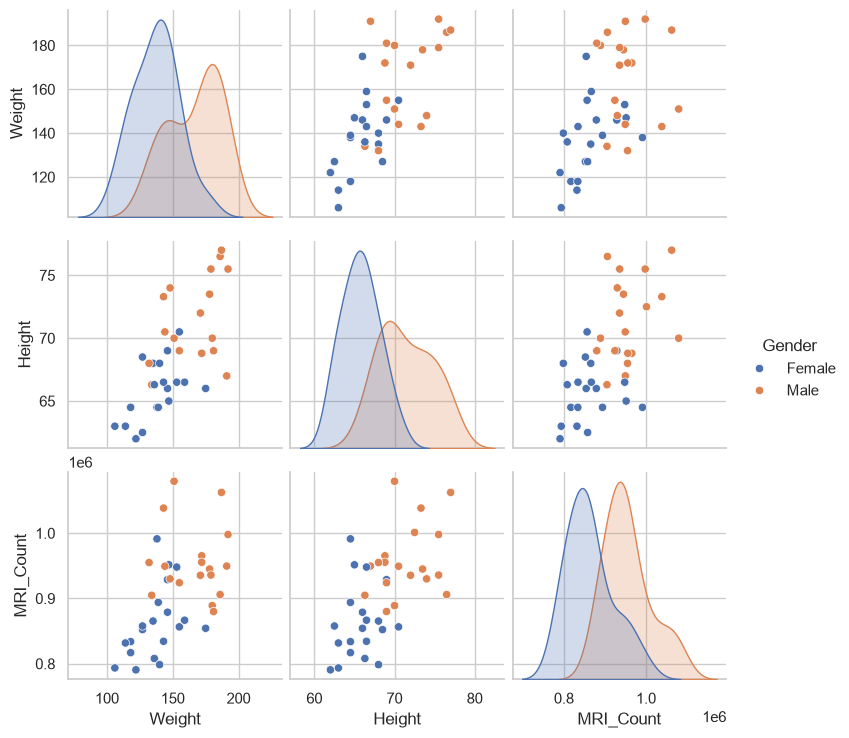

In [11]:
body_cols = ["Weight", "Height", "MRI_Count"]

sns.pairplot(brain_size, vars=body_cols, hue="Gender", corner=False)
plt.show()

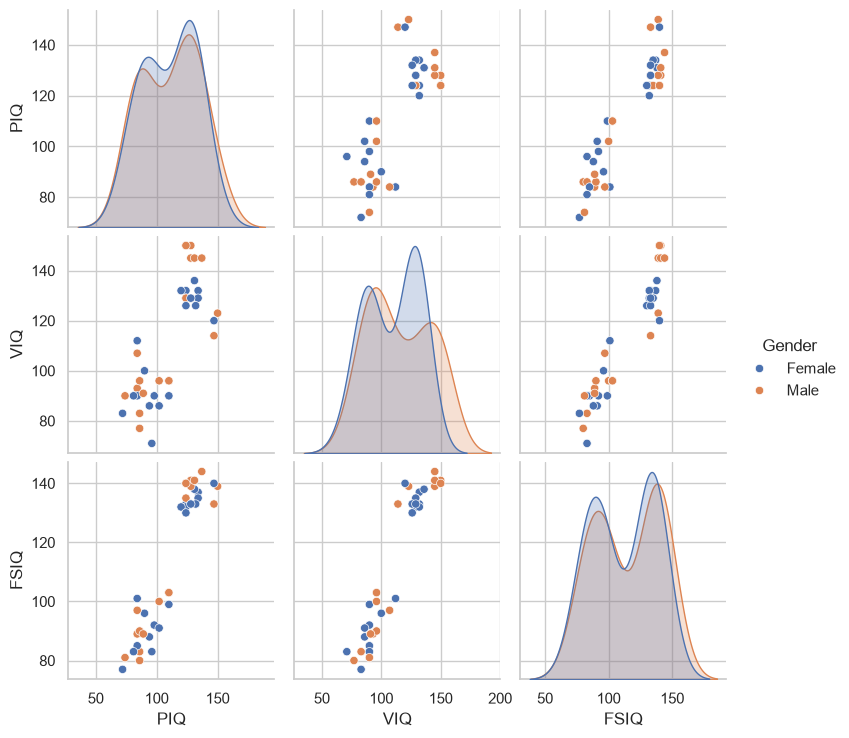

In [12]:
iq_cols = ["PIQ", "VIQ", "FSIQ"]

sns.pairplot(brain_size, vars=iq_cols, hue="Gender", corner=False)
plt.show()

## Statistics

Hypothesis tests on the brain size data.

In [13]:
viq_ttest = stats.ttest_1samp(brain_size["VIQ"], popmean=0)

print(f"t-statistic: {viq_ttest.statistic:.4f}")
print(f"p-value: {viq_ttest.pvalue:.4g}")

t-statistic: 30.0881
p-value: 1.329e-28


In [14]:
viq_wilcoxon = stats.wilcoxon(brain_size["VIQ"])

print(f"statistic: {viq_wilcoxon.statistic:.4f}")
print(f"p-value: {viq_wilcoxon.pvalue:.4g}")

statistic: 0.0000
p-value: 3.488e-08


In [15]:
female_viq = brain_size.loc[brain_size["Gender"] == "Female", "VIQ"]
male_viq = brain_size.loc[brain_size["Gender"] == "Male", "VIQ"]

viq_gender_ttest = stats.ttest_ind(female_viq, male_viq)

print(f"t-statistic: {viq_gender_ttest.statistic:.4f}")
print(f"p-value: {viq_gender_ttest.pvalue:.4g}")

t-statistic: -0.7726
p-value: 0.4445


In [16]:
viq_mannwhitney = stats.mannwhitneyu(female_viq, male_viq)

print(f"statistic: {viq_mannwhitney.statistic:.4f}")
print(f"p-value: {viq_mannwhitney.pvalue:.4g}")

statistic: 164.5000
p-value: 0.3423


In [17]:
fsiq_piq_unpaired = stats.ttest_ind(brain_size["FSIQ"], brain_size["PIQ"])

print("Unpaired t-test (FSIQ vs PIQ):")
print(f"t-statistic: {fsiq_piq_unpaired.statistic:.4f}")
print(f"p-value: {fsiq_piq_unpaired.pvalue:.4g}")

fsiq_piq_paired = stats.ttest_rel(brain_size["FSIQ"], brain_size["PIQ"])

print("\nPaired t-test (FSIQ vs PIQ):")
print(f"t-statistic: {fsiq_piq_paired.statistic:.4f}")
print(f"p-value: {fsiq_piq_paired.pvalue:.4g}")

Unpaired t-test (FSIQ vs PIQ):
t-statistic: 0.4656
p-value: 0.6428

Paired t-test (FSIQ vs PIQ):
t-statistic: 1.7842
p-value: 0.08217


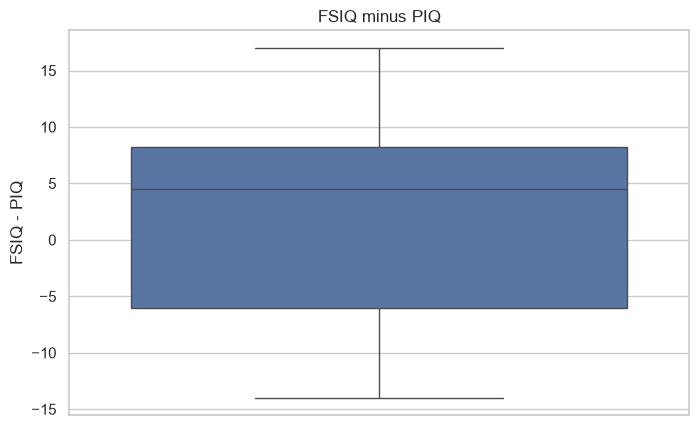

In [18]:
fsiq_piq_diff = brain_size["FSIQ"] - brain_size["PIQ"]

sns.boxplot(y=fsiq_piq_diff)
plt.ylabel("FSIQ - PIQ")
plt.title("FSIQ minus PIQ")
plt.show()

## Linear models

Simulate linear data with normally distributed noise, visualize the relationship, and fit an OLS regression model.

In [20]:
rng = np.random.default_rng(42)

n = 100
x = rng.uniform(0, 10, size=n)
noise = rng.normal(loc=0, scale=2, size=n)
y = 3 + 2 * x + noise

sim_data = pd.DataFrame({"x": x, "y": y})
display(sim_data.head())

,x,y
0,7.739560,19.278669
1,4.388784,9.966611
2,8.585979,19.415633
3,6.973680,19.545817
4,0.941773,4.171019


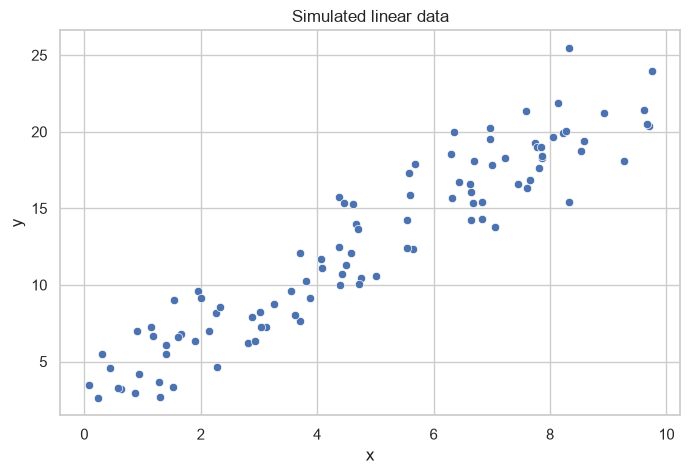

In [21]:
sns.scatterplot(data=sim_data, x="x", y="y")
plt.title("Simulated linear data")
plt.show()

In [22]:
ols_model = smf.ols("y ~ x", data=sim_data).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.887
Model:                            OLS   Adj. R-squared:                  0.886
Method:                 Least Squares   F-statistic:                     769.2
Date:                Thu, 02 Jul 2026   Prob (F-statistic):           3.41e-48
Time:                        11:37:13   Log-Likelihood:                -209.11
No. Observations:                 100   AIC:                             422.2
Df Residuals:                      98   BIC:                             427.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.8974      0.405      7.150      0.0

### VIQ by gender (brain size data)

Use OLS to compare VIQ between males and females.

In [23]:
viq_gender_ols = smf.ols("VIQ ~ C(Gender)", data=brain_size).fit()
print(viq_gender_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                    VIQ   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                 -0.010
Method:                 Least Squares   F-statistic:                    0.5969
Date:                Thu, 02 Jul 2026   Prob (F-statistic):              0.445
Time:                        11:39:14   Log-Likelihood:                -182.42
No. Observations:                  40   AIC:                             368.8
Df Residuals:                      38   BIC:                             372.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept           109.4500      5.30

### FSIQ vs PIQ (long format)

Reshape FSIQ and PIQ into long form and compare IQ by type using OLS.

In [24]:
iq_long = pd.melt(
    brain_size,
    value_vars=["FSIQ", "PIQ"],
    var_name="type",
    value_name="iq",
)[["type", "iq"]]

display(iq_long.head())
print(f"Shape: {iq_long.shape}")

,type,iq
0,FSIQ,133
1,FSIQ,140
2,FSIQ,139
3,FSIQ,133
4,FSIQ,137


Shape: (80, 2)


In [25]:
iq_type_ols = smf.ols("iq ~ C(type)", data=iq_long).fit()
print(iq_type_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                     iq   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                 -0.010
Method:                 Least Squares   F-statistic:                    0.2168
Date:                Thu, 02 Jul 2026   Prob (F-statistic):              0.643
Time:                        11:49:07   Log-Likelihood:                -364.35
No. Observations:                  80   AIC:                             732.7
Df Residuals:                      78   BIC:                             737.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        113.4500      3.683     30.

## Multiple regression

Load the iris data and explore relationships between measurements by species category.

In [26]:
iris = load_iris()
iris["categories"] = pd.Categorical(iris["name"])

display(iris.head())

,sepal_length,sepal_width,petal_length,petal_width,name,categories
0,5.1,3.5,1.4,0.2,setosa,setosa
1,4.9,3.0,1.4,0.2,setosa,setosa
2,4.7,3.2,1.3,0.2,setosa,setosa
3,4.6,3.1,1.5,0.2,setosa,setosa
4,5.0,3.6,1.4,0.2,setosa,setosa


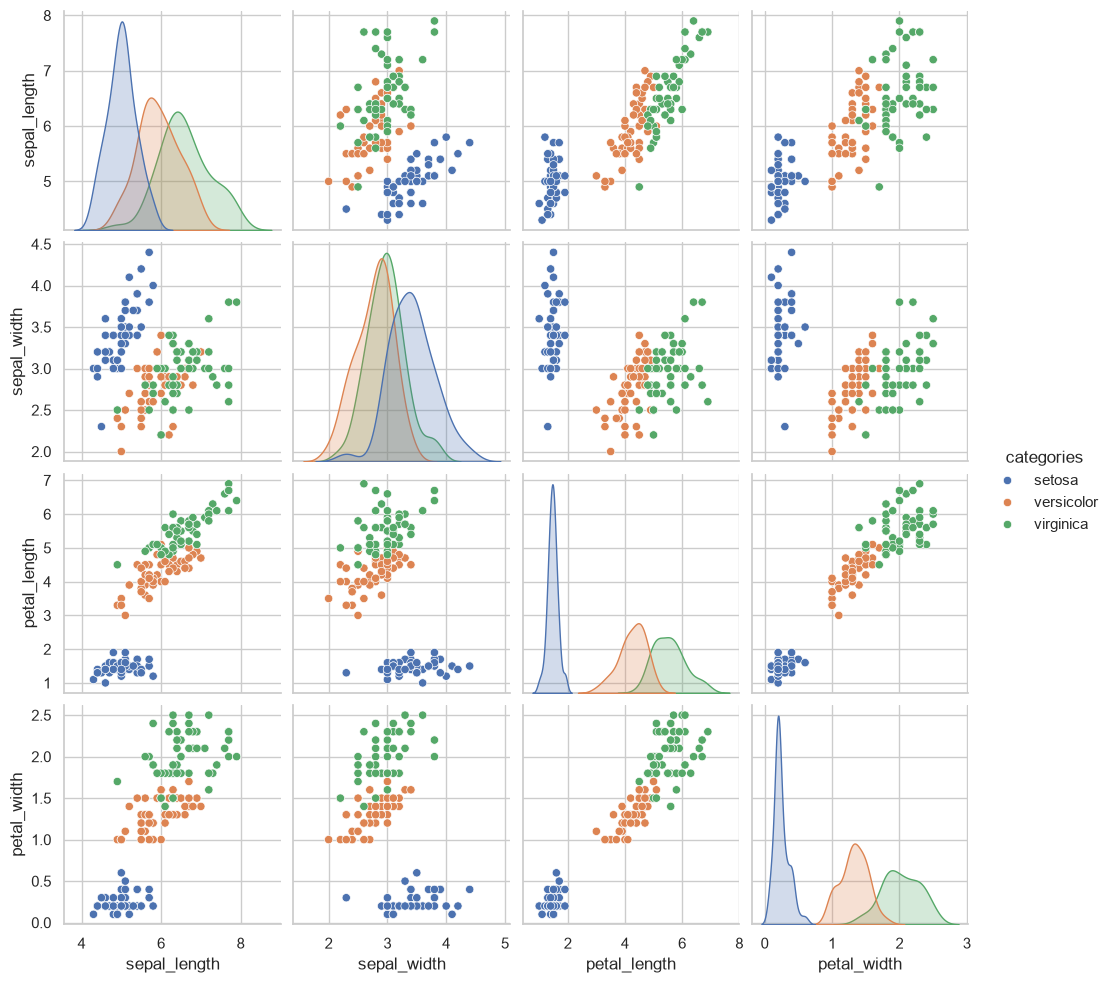

In [27]:
iris_cols = ["sepal_length", "sepal_width", "petal_length", "petal_width"]

sns.pairplot(iris, vars=iris_cols, hue="categories", corner=False)
plt.show()

In [33]:
sepal_model = smf.ols("sepal_width ~ C(name) + petal_length", data=iris).fit()
print(sepal_model.summary())

                            OLS Regression Results                            
Dep. Variable:            sepal_width   R-squared:                       0.478
Model:                            OLS   Adj. R-squared:                  0.468
Method:                 Least Squares   F-statistic:                     44.63
Date:                Thu, 02 Jul 2026   Prob (F-statistic):           1.58e-20
Time:                        12:10:42   Log-Likelihood:                -38.185
No. Observations:                 150   AIC:                             84.37
Df Residuals:                     146   BIC:                             96.41
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 2.98

In [34]:
# Contrast: versicolor coefficient - virginica coefficient = 0
# Parameter order: Intercept, C(name)[T.versicolor], C(name)[T.virginica], petal_length
contrast = np.array([0, 1, -1, 0])

versicolor_virginica_test = sepal_model.f_test(contrast)
print(versicolor_virginica_test)

<F test: F=3.2453353465741883, p=0.07369058781701086, df_denom=146, df_num=1>


## Wages

Load the wages data and explore relationships between wage, age, and education.

In [55]:
wages = load_wages()

display(wages.head())
print(f"Shape: {wages.shape}")
print(wages[["wage", "age", "education"]].dtypes)

,education,south,sex,experience,union,wage,age,race,occupation,sector,marr
0,8,0,Female,21,0,0.707570,35,2,6,1,1
1,9,0,Female,42,0,0.694605,57,3,6,1,1
2,12,0,Male,1,0,0.824126,19,3,6,1,0
3,12,0,Male,4,0,0.602060,22,3,6,0,0
4,12,0,Male,17,0,0.875061,35,3,6,0,1


Shape: (534, 11)
wage         float64
age            int64
education      int64
dtype: object


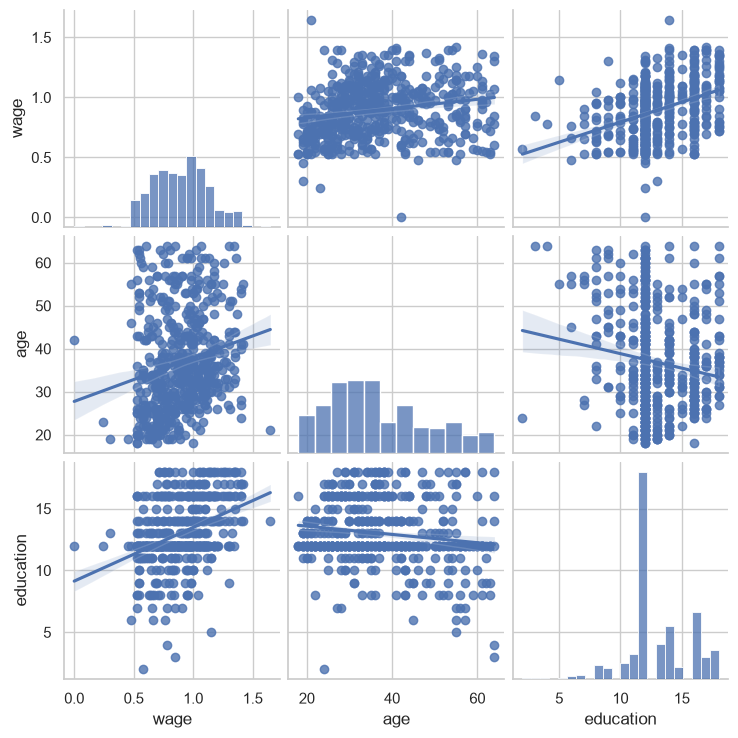

In [56]:
wages_cols = ["wage", "age", "education"]

sns.pairplot(wages, vars=wages_cols, kind="reg", corner=False)
plt.show()

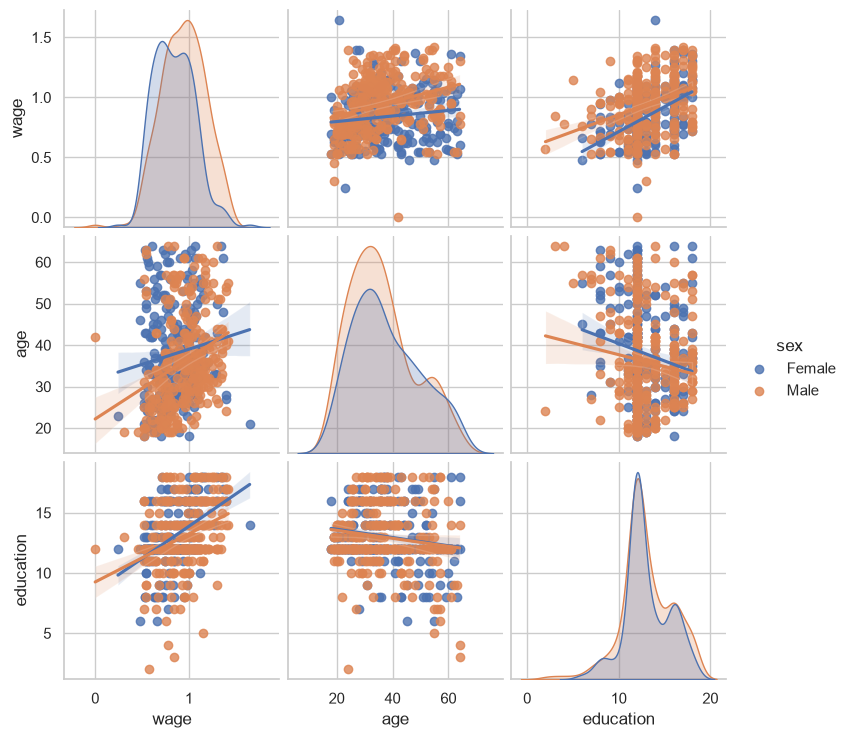

In [57]:
sns.pairplot(wages, vars=wages_cols, hue="sex", kind="reg", corner=False)
plt.show()

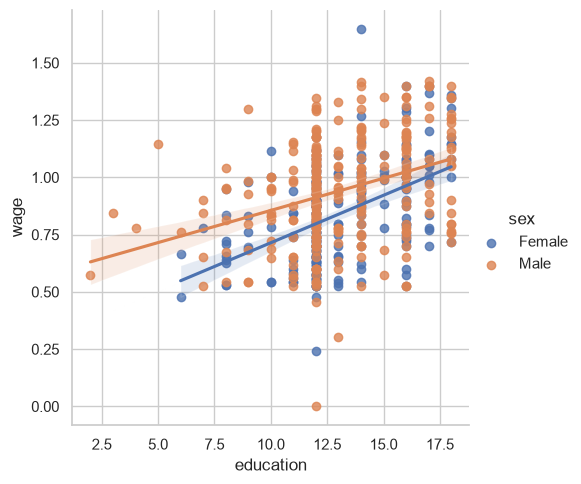

In [58]:
sns.lmplot(data=wages, x="education", y="wage", hue="sex")
plt.show()

In [59]:
wage_model = smf.ols("wage ~ education + C(sex)", data=wages).fit()
print(wage_model.summary())

                            OLS Regression Results                            
Dep. Variable:                   wage   R-squared:                       0.193
Model:                            OLS   Adj. R-squared:                  0.190
Method:                 Least Squares   F-statistic:                     63.42
Date:                Thu, 02 Jul 2026   Prob (F-statistic):           2.01e-25
Time:                        12:24:38   Log-Likelihood:                 86.654
No. Observations:                 534   AIC:                            -167.3
Df Residuals:                     531   BIC:                            -154.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          0.4053      0.046      8.

In [60]:
wage_interaction_model = smf.ols(
    "wage ~ education + C(sex) + education:C(sex)",
    data=wages,
).fit()
print(wage_interaction_model.summary())

                            OLS Regression Results                            
Dep. Variable:                   wage   R-squared:                       0.198
Model:                            OLS   Adj. R-squared:                  0.194
Method:                 Least Squares   F-statistic:                     43.72
Date:                Thu, 02 Jul 2026   Prob (F-statistic):           2.94e-25
Time:                        12:28:59   Log-Likelihood:                 88.503
No. Observations:                 534   AIC:                            -169.0
Df Residuals:                     530   BIC:                            -151.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               